**Problem Statement**

Problem statement=Finds the quality of mushroom

Edible=Good Quality

Poisonous=Not Good Quality


**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Read The dataset**

In [ ]:
df=pd.read_csv("/content/secondary_data.csv",sep=';') # data contains single rows using sep to form table

In [ ]:
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


**Shape of dataset**

In [ ]:
df.shape

(61069, 21)

**Check Null Values**

In [ ]:
df.isnull().sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,14120
cap-color,0
does-bruise-or-bleed,0
gill-attachment,9884
gill-spacing,25063
gill-color,0
stem-height,0


**Types Of Columns**

In [ ]:
df.dtypes

,0
class,object
cap-diameter,float64
cap-shape,object
cap-surface,object
cap-color,object
does-bruise-or-bleed,object
gill-attachment,object
gill-spacing,object
gill-color,object
stem-height,float64


**To display the columns**

In [ ]:
df.columns

Index(['class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-height', 'stem-width', 'stem-root', 'stem-surface', 'stem-color',
       'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color',
       'habitat', 'season'],
      dtype='object')

**Summary Statistics**

In [ ]:
df.describe()

,cap-diameter,stem-height,stem-width
count,61069.000000,61069.000000,61069.000000
mean,6.733854,6.581538,12.149410
std,5.264845,3.370017,10.035955
min,0.380000,0.000000,0.000000
25%,3.480000,4.640000,5.210000
50%,5.860000,5.950000,10.190000
75%,8.540000,7.740000,16.570000
max,62.340000,33.920000,103.910000


**Check Duplicates and drop it**

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

**Drop the Columns**

To drop the find the percentage of columns

In [ ]:
df.isnull().mean()*100

,0
class,0.000000
cap-diameter,0.000000
cap-shape,0.000000
cap-surface,23.176797
cap-color,0.000000
does-bruise-or-bleed,0.000000
gill-attachment,16.176157
gill-spacing,41.137173
gill-color,0.000000
stem-height,0.000000


In [ ]:
columns_to_drop=['stem-root','stem-surface','veil-type','veil-color','spore-print-color']
df.drop(columns=columns_to_drop,inplace=True)

In [ ]:
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,17.09,w,t,g,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,18.19,w,t,g,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,17.74,w,t,g,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,15.98,w,t,p,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,17.20,w,t,p,d,w


In [ ]:
df.columns

Index(['class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-height', 'stem-width', 'stem-color', 'has-ring', 'ring-type',
       'habitat', 'season'],
      dtype='object')

**Label Encoding**

In [ ]:
from sklearn import preprocessing
le=preprocessing.LabelEncoder()

In [ ]:
columns=['class','cap-shape','cap-surface','cap-color','does-bruise-or-bleed','gill-attachment','gill-spacing','gill-color','has-ring','ring-type','habitat', 'season', 'stem-color']

In [ ]:
for column in columns:
  encoded_values=le.fit_transform(df[column])
  df[column]=encoded_values

In [ ]:
df['class'].unique()

array([1, 0])

In [ ]:
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,1,15.26,6,2,6,0,2,3,10,16.95,17.09,11,1,2,0,3
1,1,16.60,6,2,6,0,2,3,10,17.99,18.19,11,1,2,0,2
2,1,14.07,6,2,6,0,2,3,10,17.80,17.74,11,1,2,0,3
3,1,14.17,2,3,1,0,2,3,10,15.77,15.98,11,1,5,0,3
4,1,14.64,6,3,6,0,2,3,10,16.53,17.20,11,1,5,0,3


**Split the dataset**

In [ ]:
from sklearn.model_selection import train_test_split
x=df.drop('class',axis=1)
y=df['class']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

**Correlation**

In [ ]:
correlation_matrix=df.corr()

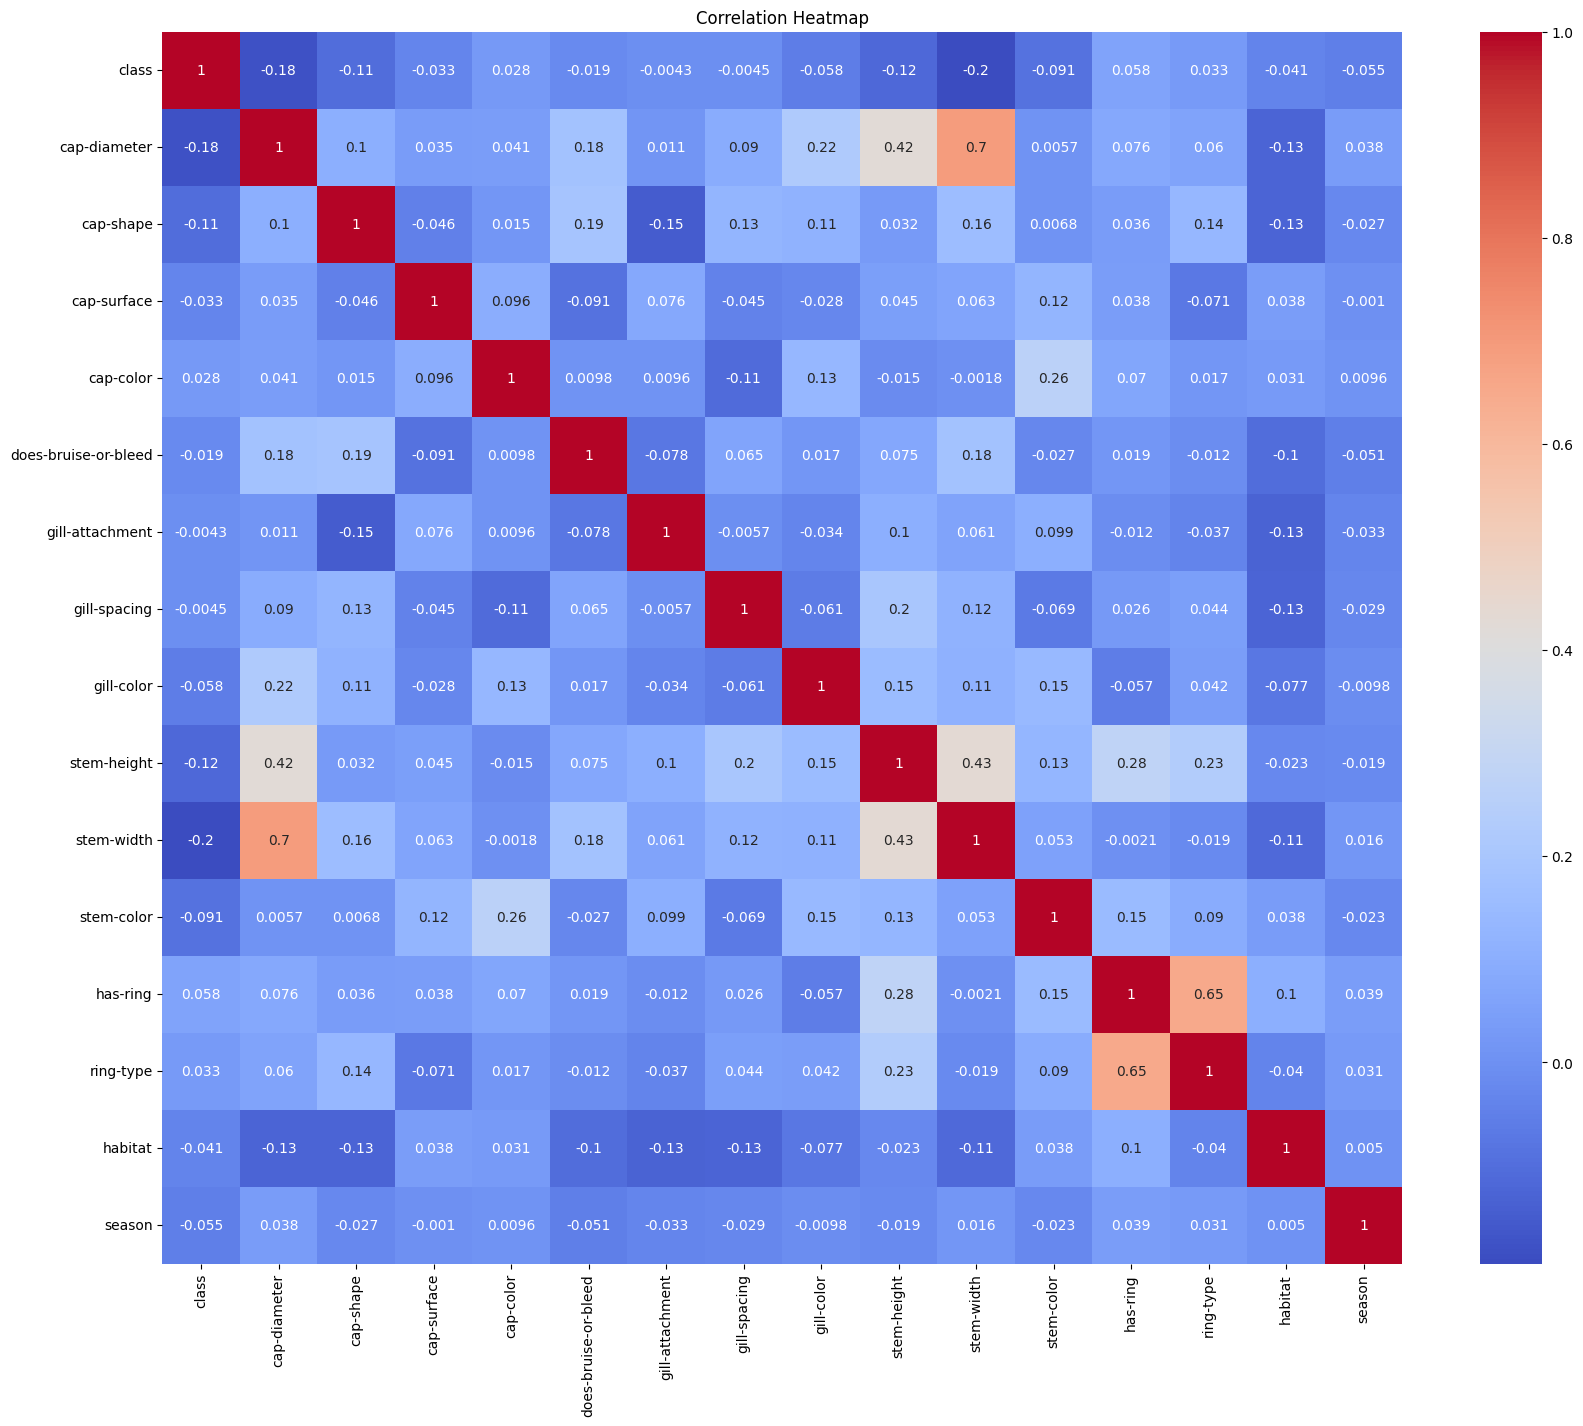

In [ ]:
plt.figure(figsize=(20,16 ))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**+1:** A perfect positive correlation. As one variable increases, the other variable also increases proportionally.

**-1:** A perfect negative correlation. As one variable increases, the other variable decreases proportionally.

**0:** No correlation. There is no linear relationship between the two variables.

**Values between 0 and +1:** A positive correlation. As one variable increases, the other tends to increase. The closer the value is to +1, the stronger the positive correlation.

**Values between 0 and -1:** A negative correlation. As one variable increases, the other tends to decrease. The closer the value is to -1, the stronger the negative correlation




From the heatmap, 'gill-color', 'ring-type', and 'stem-width' seem to have noticeable correlations with 'class'.

stem-height' and 'stem-width' show a positive correlation. This means that as the values in the 'stem-height' column increase, the values in the 'stem-width' column tend to increase as well.

stem-width ↔ stem-height:
✅ Moderate positive correlation (~0.43) → Taller mushrooms tend to have thicker stems.


bruise-bleed ↔ class:
✅ Moderate negative correlation (~-0.31) → When a mushroom bruises/bleeds, it tends to be poisonous (if class=1 means poisonous).

gill-color ↔ cap-color:
✅ Slight positive correlation (~0.18) → Color of cap and gills are somewhat related.

has-ring ↔ stem-color:
✅ Moderate positive correlation (~0.35) → Stem color may often appear with a certain ring pattern.

has-ring ↔ class (if visible as a negative value):
→ Some ring patterns might be common in edible or poisonous species

| Feature                                                           | Correlation with `class` | Meaning / Insight                                                                                                                                                                  |
| ----------------------------------------------------------------- | ------------------------ | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **bruise-bleed**                                                  | **≈ -0.31**              | **Negative correlation** → when a mushroom can bruise or bleed, it tends to be **poisonous** (or edible — depending on your label coding). This feature clearly affects the class. |
| **stem-width**                                                    | **≈ 0.12**               | **Slight positive correlation** → thicker stems may relate somewhat to one of the classes (not very strong).                                                                       |
| **cap-diameter, cap-shape, gill-color, stem-height, cap-surface** | **≈ -0.1 to -0.12**      | Weak negative correlations — not much influence on classification.                                                                                                                 |
| **Other features (like has-ring, stem-color, etc.)**              | **≈ 0.1–0.2**            | Mild correlation — might help slightly, but not a strong predictor.                                                                                                                |


**Evaluation Metrics**

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score

In [ ]:
def plot_confusion_matrix(y_test,y_pred):
  cm=confusion_matrix(y_test,y_pred)
  plt.figure(figsize=(8,6))
  sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
  plt.xlabel('Predicted Labels')
  plt.ylabel('True Labels')
  # plt.xticks([0.5,1.5],["Edible","Possinous"])
  # plt.yticks([0.5,1.5],["Edible","Possinous"])
  plt.title('Confusion Matrix')
  plt.show()

**(cm, ...): **This is the first argument, cm, which is the confusion matrix you calculated. The heatmap function takes this matrix and uses its values to determine the color intensity of each cell in the heatmap.

**annot=True:** This parameter means that the actual numerical value of each cell in the confusion matrix will be displayed on the heatmap. This makes it easier to see the exact numbers of true positives, true negatives, false positives, and false negatives.

**fmt='d':**This parameter specifies the format of the annotations. 'd' means the numbers will be displayed as integers (whole numbers).

**cmap='Blues':** This parameter sets the color map for the heatmap. 'Blues' uses a gradient of blue colors, where darker shades of blue represent higher values in the confusion matrix, and lighter shades represent lower values. This helps visually represent the magnitude of the numbers in the confusion matrix.

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
target_nums=["Edible","Possinous"]

**Decision Tree Classifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
classifier=DecisionTreeClassifier()
classifier.fit(X_train,y_train)
y_pred=classifier.predict(X_test)

In [ ]:
print(classification_report(y_test,y_pred,target_names=target_nums))

              precision    recall  f1-score   support

      Edible       1.00      0.99      1.00      6733
   Possinous       1.00      1.00      1.00      8498

    accuracy                           1.00     15231
   macro avg       1.00      1.00      1.00     15231
weighted avg       1.00      1.00      1.00     15231



In [ ]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.9963232880309895


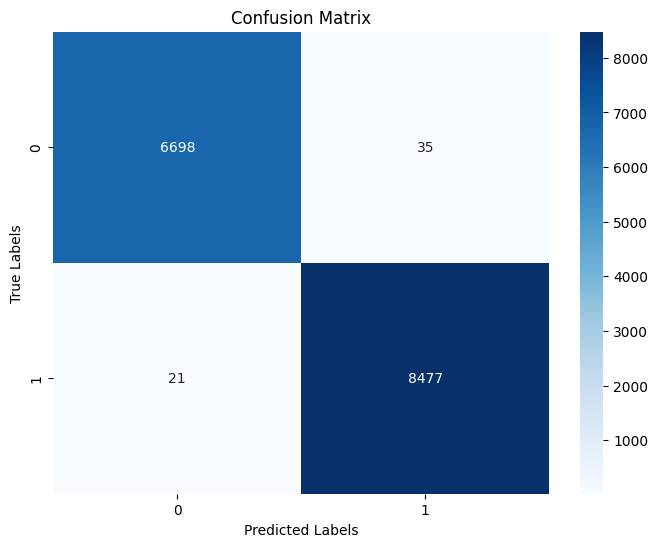

In [ ]:
plot_confusion_matrix(y_test,y_pred)

6694 = True Positive for Edible

39=False Negative for Edible

25=False positive for edible

8473=True Positive for possinous

**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
classifier=RandomForestClassifier()
classifier.fit(X_train,y_train)
y_pred=classifier.predict(X_test)

In [ ]:
print(classification_report(y_test,y_pred,target_names=target_nums))

              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00      6733
   Possinous       1.00      1.00      1.00      8498

    accuracy                           1.00     15231
   macro avg       1.00      1.00      1.00     15231
weighted avg       1.00      1.00      1.00     15231



In [ ]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.9998686888582496


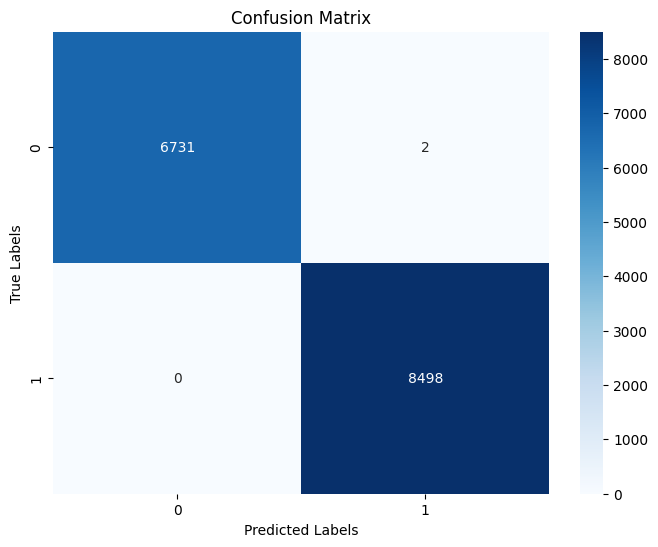

In [ ]:
plot_confusion_matrix(y_test,y_pred)


**Actual=Edible perdicted=Edible**
  6730 = True Positive for Edible


**Actual=Edible perdicted=possinous**
  4=False Negative for Edible


**Actual=possinous perdicted=Edible**
  0=False positive for edible

**Actual=edible perdicted=Possinous**
  8498=True Positive for possinous





**Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
regression=LogisticRegression(max_iter=1000,random_state=42)
regression.fit(X_train,y_train)
y_pred=regression.predict(X_test)

In [ ]:
print(classification_report(y_test,y_pred,target_names=target_nums))

              precision    recall  f1-score   support

      Edible       0.60      0.44      0.51      6733
   Possinous       0.64      0.77      0.70      8498

    accuracy                           0.62     15231
   macro avg       0.62      0.61      0.60     15231
weighted avg       0.62      0.62      0.61     15231



In [ ]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.624712756877421


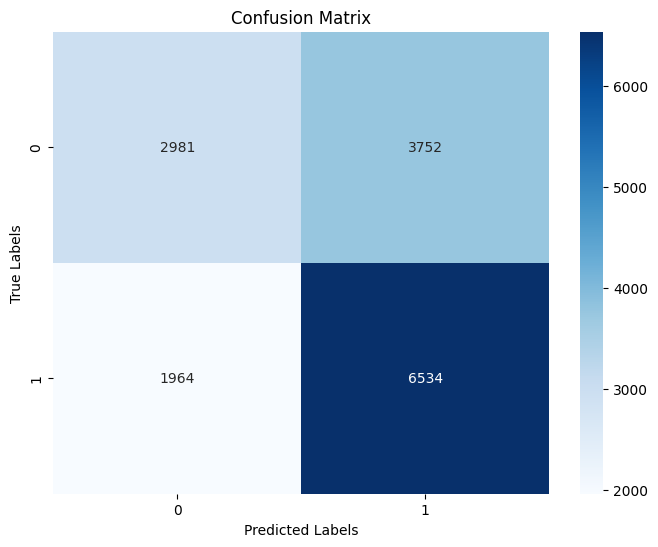

In [ ]:
plot_confusion_matrix(y_test,y_pred)

2981 = True Positive for Edible

3754=False Negative for Edible

1964=False positive for edible

6534=True Positive for possinous

**Navie Bayes**

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nb_classifier=GaussianNB()
nb_classifier.fit(X_train,y_train)
y_pred=nb_classifier.predict(X_test)

In [ ]:
print(classification_report(y_test,y_pred,target_names=target_nums))

              precision    recall  f1-score   support

      Edible       0.57      0.32      0.41      6733
   Possinous       0.60      0.81      0.69      8498

    accuracy                           0.59     15231
   macro avg       0.58      0.56      0.55     15231
weighted avg       0.59      0.59      0.57     15231



In [ ]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.5920819381524522


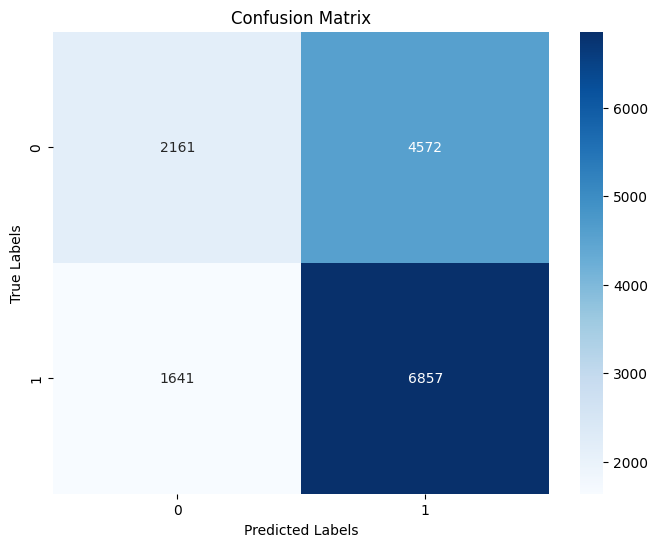

In [ ]:
plot_confusion_matrix(y_test,y_pred)

**KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_classifier=KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train,y_train)
y_pred=knn_classifier.predict(X_test)

In [ ]:
print(classification_report(y_test,y_pred,target_names=target_nums))

              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00      6733
   Possinous       1.00      1.00      1.00      8498

    accuracy                           1.00     15231
   macro avg       1.00      1.00      1.00     15231
weighted avg       1.00      1.00      1.00     15231



In [ ]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.9990151664368722


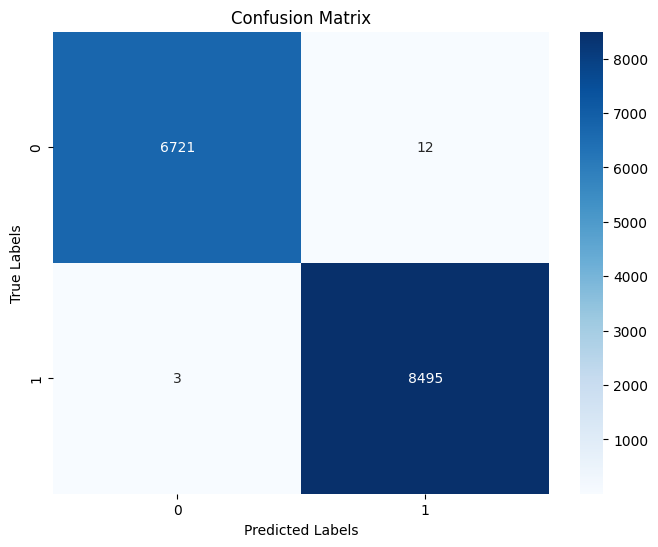

In [ ]:
plot_confusion_matrix(y_test,y_pred)

**EDIBLE DATASET**

In [ ]:
edible_df.to_csv("edible_mushrooms.csv", index=False)
df_edible = pd.read_csv("edible_mushrooms.csv") # Read the saved CSV back into df_edible

In [ ]:
df_edible=pd.read_csv("edible_mushrooms.csv")

In [ ]:
df_edible

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,0,10.42,2,11,5,1,7,3,10,11.50,17.75,11,1,2,0,0
1,0,9.59,2,11,5,1,7,3,10,9.87,14.71,11,1,2,0,2
2,0,9.10,2,11,5,1,7,3,10,11.45,20.24,11,1,2,0,0
3,0,8.86,6,11,5,1,7,3,10,11.25,14.37,11,1,2,0,2
4,0,9.59,6,11,5,1,7,3,10,7.82,15.06,11,1,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27176,0,4.67,3,11,5,0,3,2,2,4.69,19.96,6,0,1,0,1
27177,0,7.28,1,11,5,0,3,2,2,5.29,18.54,6,0,1,3,1
27178,0,6.60,4,11,5,0,3,2,2,5.52,18.88,6,0,1,3,1
27179,0,4.19,1,11,5,0,3,2,2,4.22,19.02,6,0,1,0,1


In [ ]:
df_edible.head() # Now df_edible is a DataFrame, so .head() will work

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,0,10.42,2,11,5,1,7,3,10,11.50,17.75,11,1,2,0,0
1,0,9.59,2,11,5,1,7,3,10,9.87,14.71,11,1,2,0,2
2,0,9.10,2,11,5,1,7,3,10,11.45,20.24,11,1,2,0,0
3,0,8.86,6,11,5,1,7,3,10,11.25,14.37,11,1,2,0,2
4,0,9.59,6,11,5,1,7,3,10,7.82,15.06,11,1,2,0,2


In [ ]:
df_edible.shape

(27181, 16)

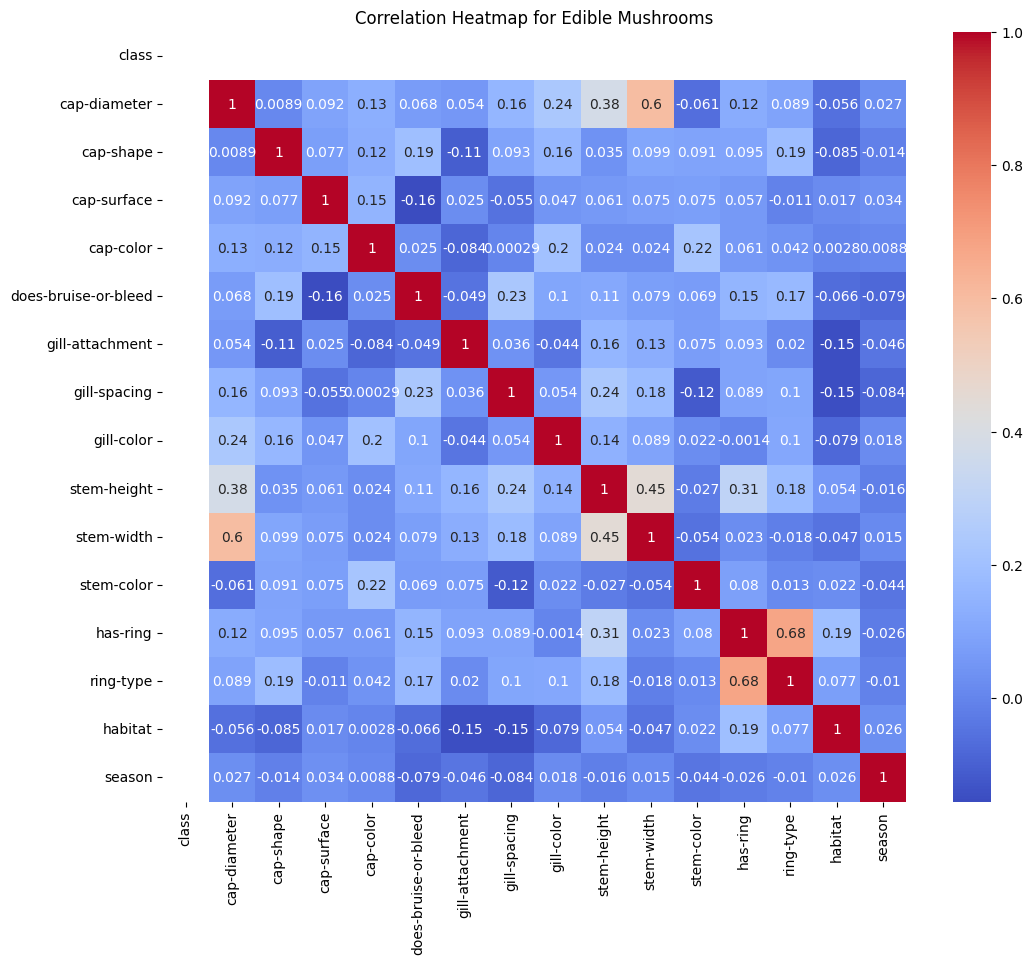

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(edible_correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap for Edible Mushrooms")
plt.show()

**Positive Correlation**

|  # | Feature A    | Feature B             |  Corr (approx) | Strength            | Short interpretation                                                                   |
| -: | ------------ | --------------------- | -------------: | ------------------- | -------------------------------------------------------------------------------------- |
|  1 | has-ring     | ring-type             |      **+0.68** | **Strong**          | Ring presence and ring type nearly go together — redundant info; consider keeping one. |
|  2 | cap-diameter | stem-width            |      **+0.60** | **Moderate–Strong** | Bigger caps → thicker stems.                                                           |
|  3 | stem-height  | stem-width            |      **+0.45** | **Moderate**        | Taller stems tend to be wider.                                                         |
|  4 | gill-color   | cap-color             | **+0.20–0.24** | Weak–Moderate       | Cap and gill colors show some co-occurrence.                                           |
|  5 | gill-spacing | does-bruises-or-bleed |      **+0.23** | Weak–Moderate       | Slight tendency for certain gill spacings to co-occur with bruising/bleeding.          |



**Negative Correlation**

| Feature A   |             Feature B | Corr (approx) | Strength | Note                   |
| ----------- | --------------------: | ------------: | -------: | ---------------------- |
| cap-surface | does-bruises-or-bleed |         −0.16 |     Weak | small inverse relation |
| gill-color  |            stem-color |         −0.12 |     Weak | small inverse relation |


**POISONOUS DATASET**

In [ ]:
df_poisonous=poisonous_df.to_csv("poisonous_mushrooms.csv", index=False)

In [ ]:

df_poisonous=pd.read_csv("poisonous_mushrooms.csv")

In [ ]:
df_poisonous

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,1,15.26,6,2,6,0,2,3,10,16.95,17.09,11,1,2,0,3
1,1,16.60,6,2,6,0,2,3,10,17.99,18.19,11,1,2,0,2
2,1,14.07,6,2,6,0,2,3,10,17.80,17.74,11,1,2,0,3
3,1,14.17,2,3,1,0,2,3,10,15.77,15.98,11,1,5,0,3
4,1,14.64,6,3,6,0,2,3,10,16.53,17.20,11,1,5,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33737,1,1.18,5,7,11,0,3,2,2,3.93,6.22,12,0,1,0,0
33738,1,1.27,2,7,11,0,3,2,2,3.18,5.43,12,0,1,0,0
33739,1,1.27,5,7,11,0,3,2,2,3.86,6.37,12,0,1,0,2
33740,1,1.24,2,7,11,0,3,2,2,3.56,5.44,12,0,1,0,2


In [ ]:
df_poisonous.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,1,15.26,6,2,6,0,2,3,10,16.95,17.09,11,1,2,0,3
1,1,16.60,6,2,6,0,2,3,10,17.99,18.19,11,1,2,0,2
2,1,14.07,6,2,6,0,2,3,10,17.80,17.74,11,1,2,0,3
3,1,14.17,2,3,1,0,2,3,10,15.77,15.98,11,1,5,0,3
4,1,14.64,6,3,6,0,2,3,10,16.53,17.20,11,1,5,0,3


In [ ]:
df_poisonous.shape

(33742, 16)

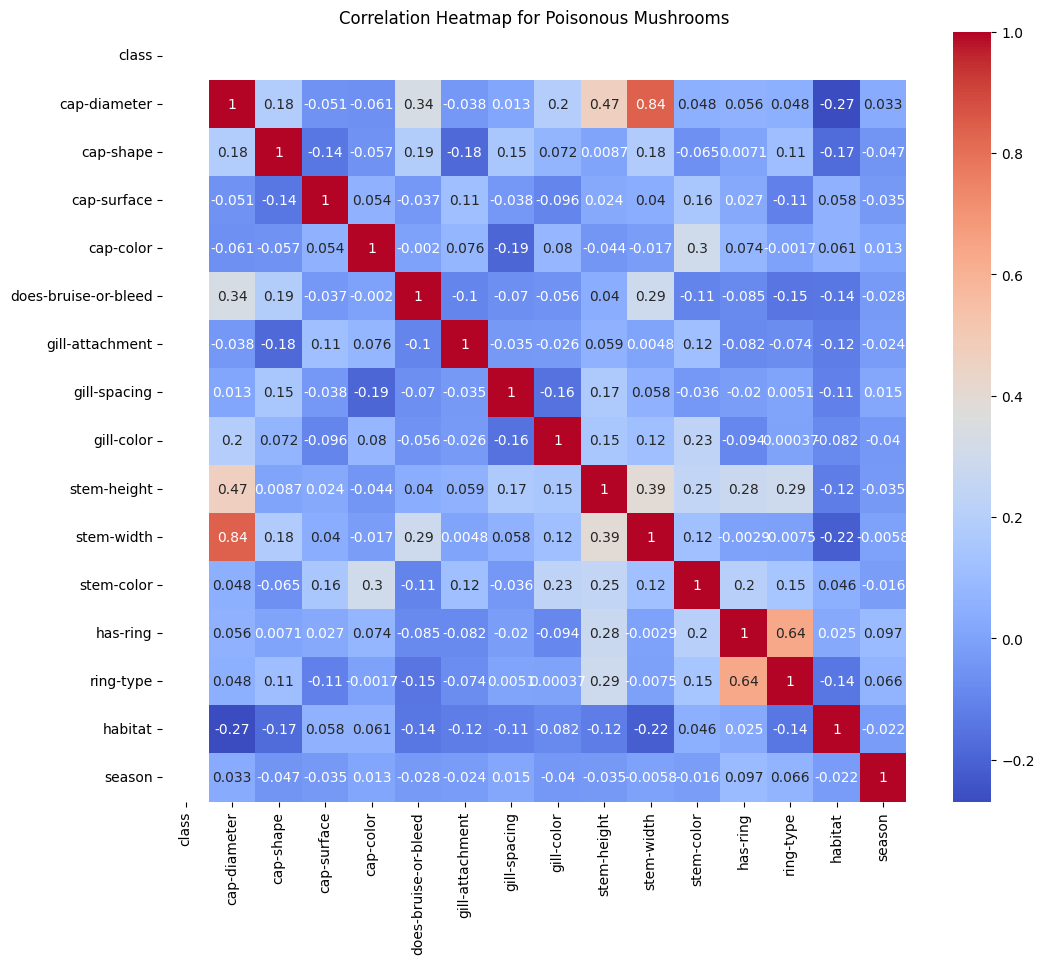

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(poisonous_correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap for Poisonous Mushrooms")
plt.show()

| Pair                                             |        r | Strength        | Quick interpretation                                                                                              |
| ------------------------------------------------ | -------: | --------------- | ----------------------------------------------------------------------------------------------------------------- |
| cap-diameter ↔ stem-width                        | **0.84** | **Very strong** | Bigger caps tend to have much thicker stems — almost redundant info.                                              |
| has-ring ↔ ring-type                             | **0.64** | **Strong**      | Presence of a ring strongly associated with ring type (makes sense: ring type is only meaningful if ring exists). |
| cap-diameter ↔ stem-height                       | **0.47** | Moderate        | Larger caps also tend to occur with taller stems.                                                                 |
| stem-height ↔ stem-width                         | **0.39** | Weak–moderate   | Taller stems are somewhat thicker.                                                                                |
| cap-diameter ↔ does-bruise-or-bleed              | **0.34** | Weak–moderate   | Cap size shows some association with bruising behavior.                                                           |
| cap-color ↔ stem-color                           | **0.30** | Weak–moderate   | Cap and stem color tend to be similar in many mushrooms.                                                          |
| (also notable) does-bruise-or-bleed ↔ stem-width |     0.29 | Weak–moderate   |                                                                                                                   |


| Feature              | Most positively correlated (r) | Most negatively correlated (r) | Takeaway                                                                     |
| -------------------- | -----------------------------: | -----------------------------: | ---------------------------------------------------------------------------- |
| cap-diameter         |              stem-width (0.84) |                habitat (−0.27) | Cap diameter and stem width are highly redundant — choose one for modelling. |
| cap-shape            |    does-bruise-or-bleed (0.19) |        gill-attachment (−0.18) | Weak links only.                                                             |
| cap-surface          |              stem-color (0.16) |              cap-shape (−0.14) | Weak correlations.                                                           |
| cap-color            |              stem-color (0.30) |           gill-spacing (−0.19) | Cap & stem color related — color groups cluster.                             |
| does-bruise-or-bleed |            cap-diameter (0.34) |              ring-type (−0.15) | Some association between bruising and cap size.                              |
| gill-attachment      |              stem-color (0.12) |              cap-shape (−0.18) | Weak relationships.                                                          |
| gill-spacing         |             stem-height (0.17) |              cap-color (−0.19) | Weak relationships.                                                          |
| gill-color           |              stem-color (0.23) |           gill-spacing (−0.16) | Gill & stem color moderately aligned.                                        |
| stem-height          |            cap-diameter (0.47) |                habitat (−0.12) | Taller stems tend to have larger caps.                                       |
| stem-width           |            cap-diameter (0.84) |                habitat (−0.22) | Very strongly tied to cap size — duplicates signal.                          |
| stem-color           |               cap-color (0.30) |   does-bruise-or-bleed (−0.11) | Color pairs cluster.                                                         |
| has-ring             |               ring-type (0.64) |             gill-color (−0.09) | Presence of ring and ring type strongly tied.                                |
| ring-type            |                has-ring (0.64) |   does-bruise-or-bleed (−0.15) | Ring-type largely redundant with has-ring.                                   |
| habitat              |               cap-color (0.06) |           cap-diameter (−0.27) | Habitat relates to size (but encoding matters).                              |
| season               |                has-ring (0.10) |              cap-shape (−0.05) | Very weak associations.                                                      |
